# Build basic 2-Layer MLP to solve the xor-Problem

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs #for data generatio

In [2]:
X, y = make_blobs(n_samples=200, n_features=2, cluster_std=.1
                  ,centers= [(1,1), (1,0), (0,0),(0,1)])

In [3]:
y[y==2]=0
y[y==3]=1

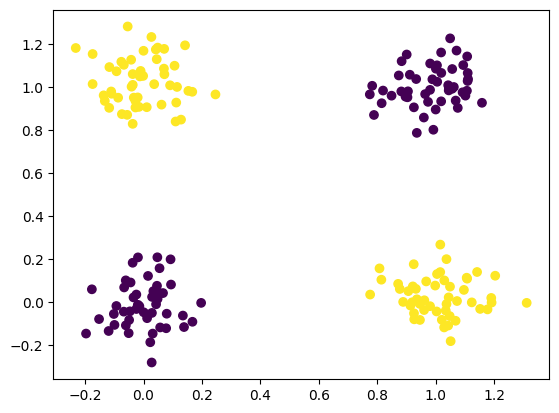

In [4]:
plt.scatter(X[:,0],X[:,1],c=y)

## Steps:
* build train and test sets
* write MLP class in Pytorch with two layers with adjustable number of perceptrons
* use nn.linear and nn.Sigmoid() units
* train your model
* test your model

In [29]:
import torch
class MLP(torch.nn.Module): #all nets inherit from nn.Module
    def __init__(self): #define layer types
        super(MLP, self).__init__()
        self.fc1 = torch.nn.Linear(2,8,bias=False) #1st layer input dim = 2, output =8 - | input needs to have size of data
        self.fc2 = torch.nn.Linear(8,1,bias=True) #2nd layer input 8 out put 2 | output needs to be one for binary problem
        self.non_linear = torch.nn.Sigmoid() #non-linear activation

    def forward(self, x): #build network
        output = self.fc1(x) #w*X
        output = self.non_linear(output) # activation
        output = self.fc2(output) #w*X
        output = self.non_linear(output) # activation

        return output

In [30]:

from sklearn.model_selection import train_test_split #for test set generation
#split in train and test
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

#np->torch
x_train = torch.FloatTensor(x_train)
x_test = torch.FloatTensor(x_test)
y_train = torch.FloatTensor(y_train)
y_test = torch.FloatTensor(y_test)


In [31]:
print(x_train.shape,y_train.shape)

torch.Size([134, 2]) torch.Size([134])


In [32]:
#get instance of perceptron model
model = MLP()

#define loss function
criterion = torch.nn.BCELoss()

#define optimizer -> SGD with learning rate lr
optimizer = torch.optim.SGD(model.parameters(), lr = 0.1)

In [33]:
#show model
print(model)

MLP(
  (fc1): Linear(in_features=2, out_features=8, bias=False)
  (fc2): Linear(in_features=8, out_features=1, bias=True)
  (non_linear): Sigmoid()
)


In [34]:
model.train() #set to train mode
iterations = 10000
for iter in range(iterations):
    optimizer.zero_grad()
    # Forward pass
    y_pred = model(x_train)
    # Compute Loss
    loss = criterion(y_pred.squeeze(), y_train)

    print('Iter {}: train loss: {}'.format(iter, loss.item()))
    # Backward pass
    loss.backward()
    #make gradient update
    optimizer.step()

Streaming output truncated to the last 5000 lines.
Iter 5000: train loss: 0.1878548413515091
Iter 5001: train loss: 0.18772265315055847
Iter 5002: train loss: 0.1875905692577362
Iter 5003: train loss: 0.1874585896730423
Iter 5004: train loss: 0.18732674419879913
Iter 5005: train loss: 0.18719501793384552
Iter 5006: train loss: 0.18706339597702026
Iter 5007: train loss: 0.18693187832832336
Iter 5008: train loss: 0.18680046498775482
Iter 5009: train loss: 0.18666918575763702
Iter 5010: train loss: 0.18653801083564758
Iter 5011: train loss: 0.1864069253206253
Iter 5012: train loss: 0.18627597391605377
Iter 5013: train loss: 0.1861451119184494
Iter 5014: train loss: 0.18601436913013458
Iter 5015: train loss: 0.1858837604522705
Iter 5016: train loss: 0.18575327098369598
Iter 5017: train loss: 0.18562284111976624
Iter 5018: train loss: 0.18549256026744843
Iter 5019: train loss: 0.18536239862442017
Iter 5020: train loss: 0.18523231148719788
Iter 5021: train loss: 0.18510237336158752
Iter 5022

In [35]:
#train error
y_pred = model(x_train) #predict
y_pred=(y_pred>0.5).int().flatten() #argmax class lable
test_acc = torch.sum(y_pred == y_train.int()) /y_train.shape[0]
print("test ACC: ",test_acc.float())

test ACC:  tensor(1.)


In [36]:
#test error
y_pred = model(x_test) #predict
y_pred=(y_pred>0.5).int().flatten() #argmax class lable
test_acc = torch.sum(y_pred == y_test.int()) /y_test.shape[0]
print("test ACC: ",test_acc.float())

test ACC:  tensor(1.)
